# AG News Dataset: Exploratory Data Analysis Summary

###  Dataset Structure
*   **Total Records:** 120,000 rows
*   **Columns:** 4 (`Title`, `Description`, `Topic`, `Full_Text`)
*   **Target Column:** `Topic` (int64)
*   **Text Columns:** `Title`, `Description`, `Full_Text` (object)

###  Class Distribution
The dataset is perfectly balanced across four categories, with 30,000 samples each:
1. **World**
2. **Sports**
3. **Business**
4. **Sci/Tech**

###  Text Analysis
*   **Word Count:**
    *   Minimum: 9 words
    *   Maximum: 178 words
    *   **Average: 38.85 words**
*   **Sample Record:**
    > "Wall St. Bears Claw Back Into the Black (Reuters) - Reuters - Short-sellers, Wall Street's dwindling band of ultra-cynics, are seeing green again."

###  Data Quality & Noise
*   **Missing Values:** 0 (Clean)
*   **URLs Detected:** 1,791 rows
*   **HTML Tags:** 0 detected
*   **Special Characters:** Present in all 120,000 rows (Requires cleaning)

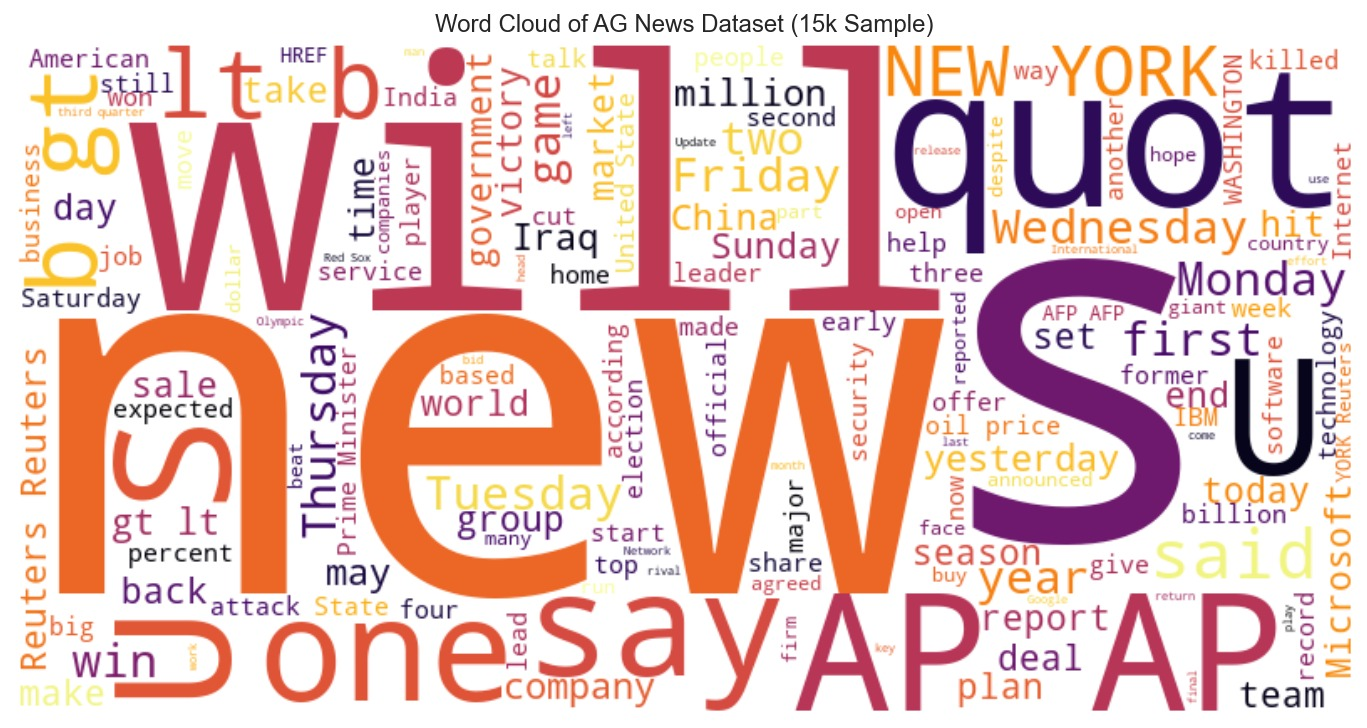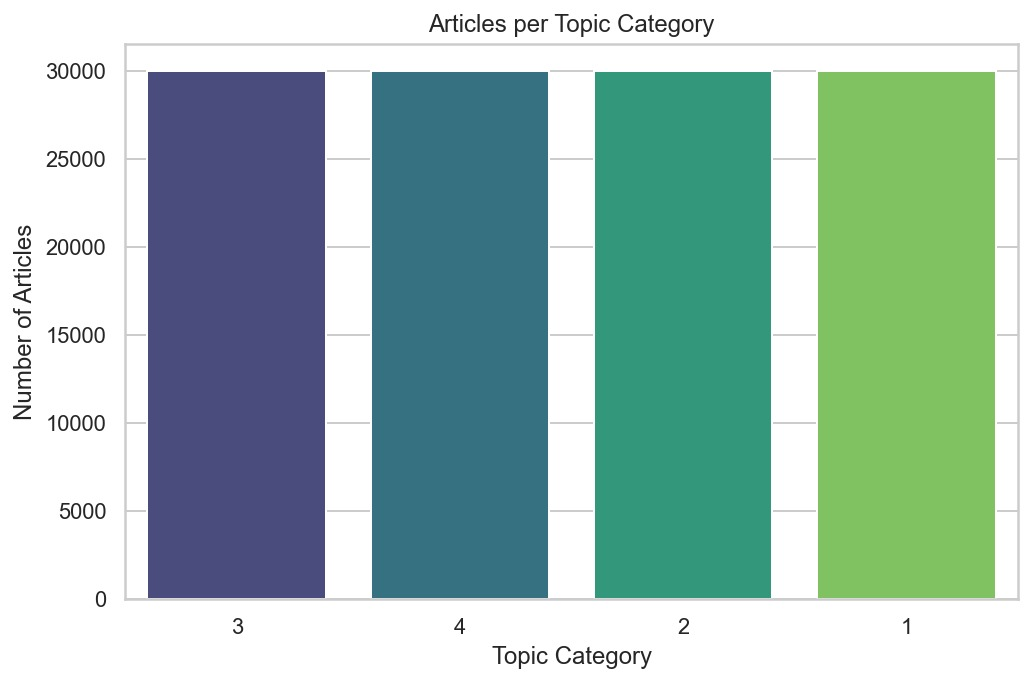

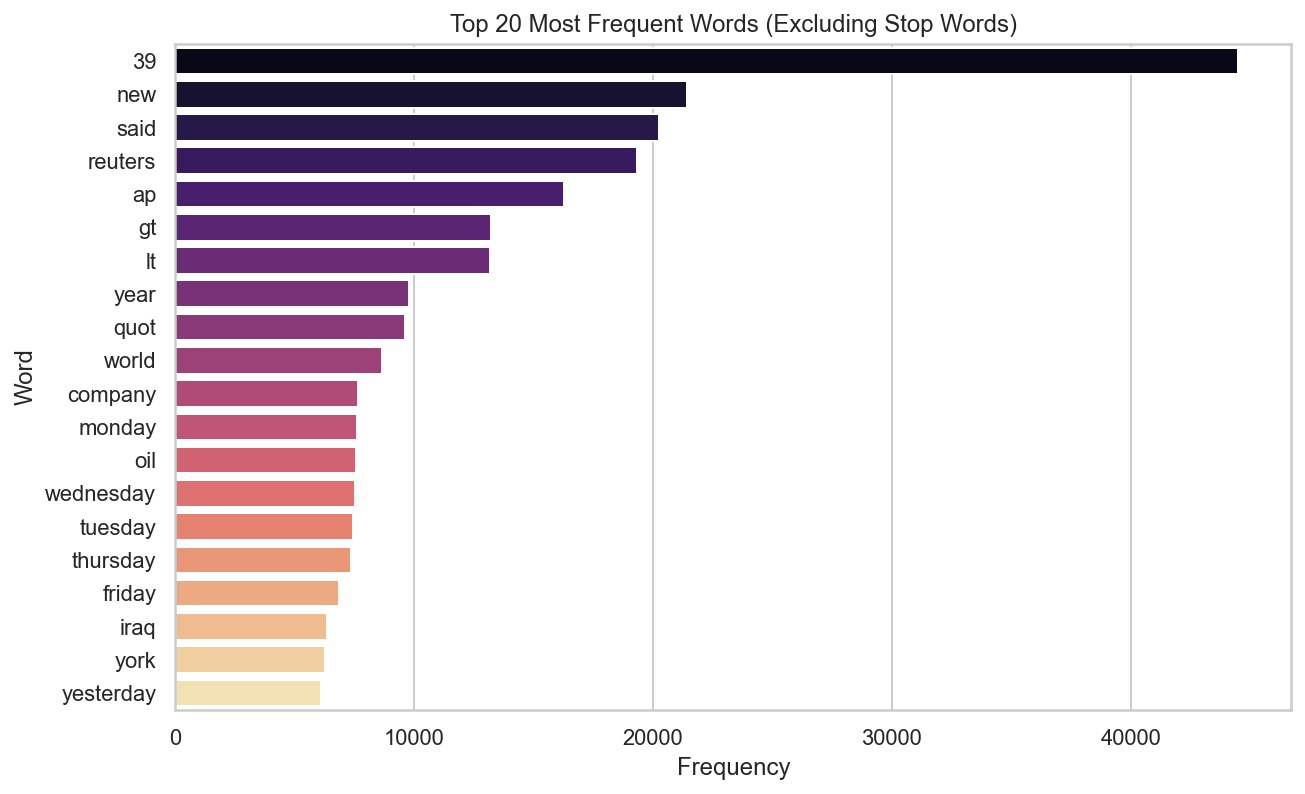

In [1]:
!pip install gensim
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from gensim.models import Word2Vec # 1. Import Word2Vec from Gensim

# --- 1. Load the Data ---
print("Loading data...")
url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv"
df = pd.read_csv(url, header=None, names=['Topic', 'Title', 'Description'])

cols = [col for col in df.columns if col != 'Topic'] + ['Topic']
df = df[cols]
df['Full_Text'] = df['Title'] + " " + df['Description']

# --- 2. Define the Cleaning, POS Tagging, & Lemmatization ---
print("Downloading NLTK resources...")
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]|_', '', text)

    words = word_tokenize(text)
    pos_tags = nltk.pos_tag(words)

    cleaned_words = []
    for word, tag in pos_tags:
        if word not in stop_words:
            wn_tag = get_wordnet_pos(tag)
            lemmatized_word = lemmatizer.lemmatize(word, pos=wn_tag)
            cleaned_words.append(lemmatized_word)

    return ' '.join(cleaned_words)

# --- 3. Create the Cleaned DataFrame ---
print("Building the cleaned dataset (this may take a few minutes)...")
# Note: Using .head(5000) here is highly recommended for testing.
# Full dataset will take a long time to clean.
df_cleaned = pd.DataFrame()
df_cleaned['Clean_Text'] = df['Full_Text'].apply(clean_text)
df_cleaned['Topic'] = df['Topic']


# --- 4. The Embedding Process (Word2Vec) ---
print("\nPreparing text for Embeddings...")

# Word2Vec expects a list of lists containing words: [['word1', 'word2'], ['word3', 'word4']]
# We split our cleaned string sentences back into lists of words
tokenized_sentences = df_cleaned['Clean_Text'].apply(lambda x: x.split()).tolist()

print("Training Word2Vec model...")
# Initialize and train the Word2Vec model
# vector_size = How many dimensions each word gets mapped to (usually 100-300)
# window = How many surrounding words to look at to determine context
# min_count = Ignore words that appear fewer times than this across the dataset
w2v_model = Word2Vec(sentences=tokenized_sentences, vector_size=100, window=5, min_count=2, workers=4)

print("\n--- Embedding Summary ---")
vocab_size = len(w2v_model.wv)
print(f"Total Unique Embedded Words: {vocab_size}")

print("\n--- Embedding Output Examples ---")

# Example A: Look up the dense numerical vector for a specific word
sample_word = "computer"
if sample_word in w2v_model.wv:
    vector = w2v_model.wv[sample_word]
    print(f"Vector shape for '{sample_word}': {vector.shape} dimensions")
    # Print just the first 5 numbers of the 100-dimension vector
    print(f"First 5 values of '{sample_word}' array: {vector[:5]}")
else:
    print(f"Word '{sample_word}' not in vocabulary.")

# Example B: Find words that have similar meanings/contexts based on the embeddings!
test_word = "game"
if test_word in w2v_model.wv:
    print(f"\nMost mathematically similar words to '{test_word}':")
    similar_words = w2v_model.wv.most_similar(test_word, topn=3)
    for word, score in similar_words:
        print(f" - {word} (Similarity: {score:.4f})")

Loading data...
Building the cleaned dataset (this may take a few minutes)...

Preparing text for Embeddings...
Training Word2Vec model...

--- Embedding Summary ---
Total Unique Embedded Words: 42321

--- Embedding Output Examples ---
Vector shape for 'computer': (100,) dimensions
First 5 values of 'computer' array: [-1.2182527   0.5112231  -2.170827    0.09468178 -0.60220766]

Most mathematically similar words to 'game':
 - madden (Similarity: 0.5656)
 - postseason (Similarity: 0.5304)
 - videogame (Similarity: 0.5265)


### 5. Building an LSTM Classifier
LSTMs are recurrent neural networks capable of learning long-term dependencies in sequence data. Unlike the previous approach, this model will look at the order of words.

In [4]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Prepare the text data for Deep Learning
max_words = 20000
max_len = 50

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df_cleaned['Clean_Text'])
sequences = tokenizer.texts_to_sequences(df_cleaned['Clean_Text'])
word_index = tokenizer.word_index

X_deep = pad_sequences(sequences, maxlen=max_len)
# AG News labels are 1-4, Keras expects 0-indexed for sparse_categorical or one-hot
y_deep = df_cleaned['Topic'].values - 1

# 2. Create Embedding Matrix from our Word2Vec model
embedding_dim = w2v_model.vector_size
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
for word, i in word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

# 3. Build the LSTM Model
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(len(word_index) + 1,
                              embedding_dim,
                              weights=[embedding_matrix],
                              input_length=max_len,
                              trainable=False),
    tf.keras.layers.SpatialDropout1D(0.2),
    tf.keras.layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     8,143,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,143,100 (31.06 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 8,143,100 (31.06 MB)

In [11]:
# 4. Train the model
print("Training LSTM model on the full training dataset...")

# We donn't use train_test_split here because we have a separate test file
history = model.fit(X_deep, y_deep,
                    epochs=5,
                    batch_size=128,
                    validation_split=0.1,  # Still keeping a small validation split to monitor over-fitting
                    verbose=1)

Training LSTM model on the full training dataset...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 99s 111ms/step - accuracy: 0.9013 - loss: 0.2805 - val_accuracy: 0.9105 - val_loss: 0.2402
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 134s 102ms/step - accuracy: 0.9037 - loss: 0.2737 - val_accuracy: 0.9142 - val_loss: 0.2371
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 143s 104ms/step - accuracy: 0.9052 - loss: 0.2693 - val_accuracy: 0.9147 - val_loss: 0.2375
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 142s 104ms/step - accuracy: 0.9056 - loss: 0.2660 - val_accuracy: 0.9151 - val_loss: 0.2370
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 89s 106ms/step - accuracy: 0.9073 - loss: 0.2603 - val_accuracy: 0.9112 - val_loss: 0.2422


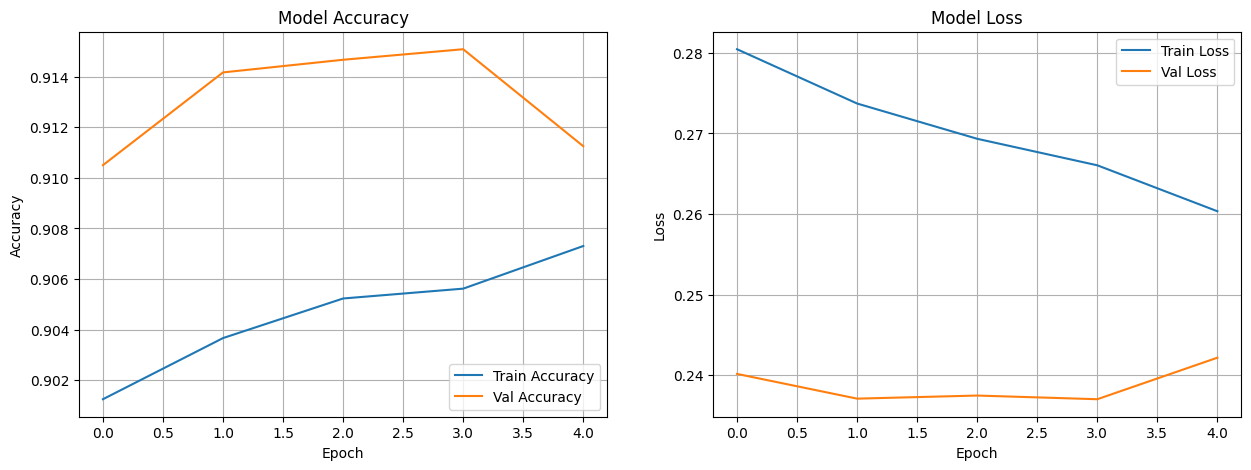

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- 1. Plot Training & Validation History ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.show()

### 6. Final evaluation
   we imported the test data set and used  the same preprocessing steps to make the final evalution

In [13]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

# 1. Load the test data
print("Loading test data...")
test_url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv"
df_test = pd.read_csv(test_url, header=None, names=['Topic', 'Title', 'Description'])
df_test['Full_Text'] = df_test['Title'] + " " + df_test['Description']

# 2. Preprocess using the SAME steps
print("Cleaning test data...")
df_test['Clean_Text'] = df_test['Full_Text'].apply(clean_text)

# Tokenize and pad using the existing tokenizer and max_len
test_sequences = tokenizer.texts_to_sequences(df_test['Clean_Text'])
X_test = pad_sequences(test_sequences, maxlen=max_len)
y_test = df_test['Topic'].values - 1

# 3. Final Evaluation
print("\nEvaluating LSTM model on the official test set...")
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

# 4. Predictions and Report
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\nLSTM Classification Report (Official Test Set):")
print(classification_report(y_test, y_pred, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))

Loading test data...
Cleaning test data...

Evaluating LSTM model on the official test set...
Test Accuracy: 0.9082
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step

LSTM Classification Report (Official Test Set):
              precision    recall  f1-score   support

       World       0.93      0.91      0.92      1900
      Sports       0.95      0.98      0.96      1900
    Business       0.89      0.85      0.87      1900
    Sci/Tech       0.87      0.90      0.88      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



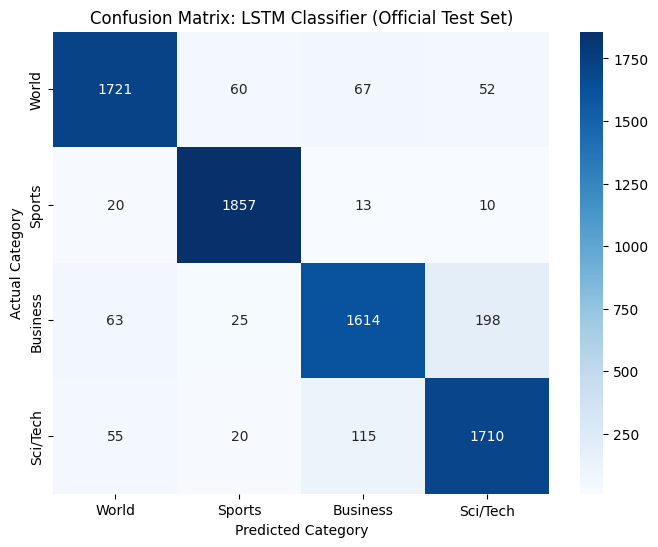

In [16]:
# --- 2. Generate Confusion Matrix ---
class_names = ['World', 'Sports', 'Business', 'Sci/Tech']
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: LSTM Classifier (Official Test Set)')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

### 6. Saving the Models
We will save the Word2Vec embeddings and the trained LSTM classifier to the local Colab environment.

In [14]:
# Save the Word2Vec model
w2v_model.save("word2vec_ag_news.model")
print("Word2Vec model saved as 'word2vec_ag_news.model'")

# Save the LSTM model
model.save("lstm_classifier.keras")
print("LSTM model saved as 'lstm_classifier.keras'")

Word2Vec model saved as 'word2vec_ag_news.model'
LSTM model saved as 'lstm_classifier.keras'


You can find these files in the **Files** pane on the left. To download them to your computer, right-click the file and select **Download**.